# Augmentasi Data Spektrum Gamma

Augmentasi data spektrum gamma dengan **random Gaussian noise** pada tiga level SNR: **10 dB, 20 dB, 30 dB**.

- **Input** : `DATA FIX (Belum Augmentasi).xlsx` (800 data)
- **Output**: `DATA FIX (Sudah Augmentasi).xlsx` (3200 data)
- Total = 800 original + 800 (SNR 10 dB) + 800 (SNR 20 dB) + 800 (SNR 30 dB) = **3200**

Data diurutkan berdasarkan `Kode Sampel` (1 - 15) dan dalam tiap kode urutannya: Original -> SNR_10dB -> SNR_20dB -> SNR_30dB. Sheet `Grafik` dan `Aktivitas` dijamin saling sejajar (row-aligned).

## 1. Import Library & Konfigurasi

In [1]:
import numpy as np
import openpyxl
import xlsxwriter
import time

np.random.seed(42)  # reproducibility

INPUT_FILE  = r"C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\DATA FIX (Belum Augmentasi).xlsx"
OUTPUT_FILE = r"C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\DATA FIX (Sudah Augmentasi).xlsx"

SNR_LEVELS = [10, 20, 30]   # dB
N_CHANNELS = 1024

## 2. Fungsi Penambah Noise Gaussian

Formula:
$$\sigma_{noise} = \sqrt{\frac{P_{signal}}{10^{SNR/10}}} \qquad P_{signal} = \overline{x^2}$$

Nilai negatif di-clip ke 0 (cacah foton tidak bisa negatif).

In [2]:
def add_gaussian_noise(signal: np.ndarray, snr_db: float) -> np.ndarray:
    """Tambahkan white Gaussian noise ke sinyal sesuai SNR (dB)."""
    p_signal = np.mean(signal ** 2)
    if p_signal == 0:
        return signal.copy()
    p_noise = p_signal / (10 ** (snr_db / 10.0))
    sigma   = np.sqrt(p_noise)
    noise   = np.random.normal(0.0, sigma, signal.shape)
    result  = signal + noise
    return np.clip(result, 0.0, None)

## 3. Baca Data Asli

In [3]:
print("Membaca file input ...")
wb_in = openpyxl.load_workbook(INPUT_FILE, read_only=True, data_only=True)

# --- Sheet Klasifikasi Multilabel (simpan utuh) ---
ws_klas = wb_in["Klasifikasi Multilabel"]
klas_rows = [list(r) for r in ws_klas.iter_rows(values_only=True)]

# --- Sheet Grafik ---
ws_grafik  = wb_in["Grafik"]
grafik_all = [list(r) for r in ws_grafik.iter_rows(values_only=True)]
grafik_data = grafik_all[1:]   # 800 baris data (lewati header)

grafik_kode     = [r[1] for r in grafik_data]
grafik_channels = np.array(
    [[0.0 if v is None else float(v) for v in r[2:2 + N_CHANNELS]]
     for r in grafik_data],
    dtype=np.float64
)

# --- Sheet Aktivitas ---
ws_akt   = wb_in["Aktivitas"]
akt_all  = [list(r) for r in ws_akt.iter_rows(values_only=True)]
akt_data = akt_all[2:]   # 800 baris data (lewati 2 baris header)

akt_kode   = [r[1] for r in akt_data]
akt_values = [r[2:6] for r in akt_data]   # (Co-60, Cs-137, Ra-226, Eu-152)

wb_in.close()
print(f"  Grafik    : {len(grafik_data)} baris, {N_CHANNELS} kanal")
print(f"  Aktivitas : {len(akt_data)} baris")

Membaca file input ...
  Grafik    : 800 baris, 1024 kanal
  Aktivitas : 800 baris


## 4. Buat Dataset Gabungan (Original + Augmented)

In [4]:
print("Membuat augmented data ...")

JENIS_URUTAN = {"Original": 0, "SNR_10dB": 1, "SNR_20dB": 2, "SNR_30dB": 3}

records_grafik    = []   # (kode, jenis, urutan_jenis, channels_ndarray)
records_aktivitas = []   # (kode, jenis, urutan_jenis, [co60, cs137, ra226, eu152])

# Data original
for i in range(len(grafik_data)):
    records_grafik.append((grafik_kode[i], "Original", 0, grafik_channels[i]))
    records_aktivitas.append((akt_kode[i], "Original", 0, akt_values[i]))

# Data augmented per SNR
for snr in SNR_LEVELS:
    label  = f"SNR_{snr}dB"
    urutan = JENIS_URUTAN[label]
    print(f"  Augmentasi SNR {snr} dB ...")
    for i in range(len(grafik_data)):
        aug = add_gaussian_noise(grafik_channels[i], snr)
        records_grafik.append((grafik_kode[i], label, urutan, aug))
        records_aktivitas.append((akt_kode[i], label, urutan, akt_values[i]))

# Urutkan: kode_sampel -> urutan_jenis (stable sort menjaga urutan asli dalam grup yang sama)
order = sorted(
    range(len(records_grafik)),
    key=lambda i: (records_grafik[i][0], records_grafik[i][2])
)
records_grafik    = [records_grafik[i]    for i in order]
records_aktivitas = [records_aktivitas[i] for i in order]

total = len(records_grafik)
print(f"\nTotal rekaman setelah augmentasi: {total}")

Membuat augmented data ...
  Augmentasi SNR 10 dB ...
  Augmentasi SNR 20 dB ...
  Augmentasi SNR 30 dB ...

Total rekaman setelah augmentasi: 3200


## 5. Tulis File Output

Menggunakan `xlsxwriter` dengan mode `constant_memory` agar efisien untuk file besar (~35 MB).

In [5]:
print("Menulis file output ... (mungkin memerlukan beberapa menit)")
t0 = time.time()

workbook = xlsxwriter.Workbook(OUTPUT_FILE, {'constant_memory': True})
fmt_bold = workbook.add_format({'bold': True})

# --- Sheet 1: Klasifikasi Multilabel ---
ws_klas_out = workbook.add_worksheet("Klasifikasi Multilabel")
for r_idx, row in enumerate(klas_rows):
    for c_idx, val in enumerate(row):
        if val is not None:
            ws_klas_out.write(r_idx, c_idx, val)

# --- Sheet 2: Grafik ---
ws_grafik_out = workbook.add_worksheet("Grafik")

header_grafik = ["No", "Kode sampel", "Jenis"] + [f"Ch_{i}" for i in range(N_CHANNELS)]
for c_idx, h in enumerate(header_grafik):
    ws_grafik_out.write(0, c_idx, h, fmt_bold)

for row_i, (kode, jenis, _, channels) in enumerate(records_grafik, start=1):
    ws_grafik_out.write(row_i, 0, row_i)
    ws_grafik_out.write(row_i, 1, kode)
    ws_grafik_out.write(row_i, 2, jenis)
    ws_grafik_out.write_row(row_i, 3, channels.tolist())
    if row_i % 500 == 0:
        print(f"  Grafik: {row_i}/{total} baris ({time.time()-t0:.1f}s)")

print(f"  Sheet Grafik selesai ({time.time()-t0:.1f}s)")

# --- Sheet 3: Aktivitas ---
ws_akt_out = workbook.add_worksheet("Aktivitas")

# Header baris 1
for c_idx, h in enumerate(["No", "Kode Sampel", "Jenis", "Aktivitas"]):
    ws_akt_out.write(0, c_idx, h, fmt_bold)

# Header baris 2 (sub-header isotop)
for c_idx, h in enumerate(["Co-60", "Cs-137", "Ra-226", "Eu-152"], start=3):
    ws_akt_out.write(1, c_idx, h, fmt_bold)

for row_i, (kode, jenis, _, vals) in enumerate(records_aktivitas, start=2):
    ws_akt_out.write(row_i, 0, row_i - 1)
    ws_akt_out.write(row_i, 1, kode)
    ws_akt_out.write(row_i, 2, jenis)
    for c_idx, v in enumerate(vals, start=3):
        if v is not None:
            ws_akt_out.write(row_i, c_idx, v)

print(f"  Sheet Aktivitas selesai ({time.time()-t0:.1f}s)")

workbook.close()

print(f"\nFile tersimpan : {OUTPUT_FILE}")
print(f"Waktu total    : {time.time()-t0:.1f} detik")
print(f"Rekaman Grafik : {total} baris")
print(f"Rekaman Akt.   : {total} baris")

Menulis file output ... (mungkin memerlukan beberapa menit)
  Grafik: 500/3200 baris (1.6s)
  Grafik: 1000/3200 baris (3.1s)
  Grafik: 1500/3200 baris (4.7s)
  Grafik: 2000/3200 baris (6.2s)
  Grafik: 2500/3200 baris (7.8s)
  Grafik: 3000/3200 baris (9.3s)
  Sheet Grafik selesai (10.0s)
  Sheet Aktivitas selesai (10.1s)

File tersimpan : C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\DATA FIX (Sudah Augmentasi).xlsx
Waktu total    : 14.7 detik
Rekaman Grafik : 3200 baris
Rekaman Akt.   : 3200 baris


## 6. Verifikasi Hasil

In [6]:
import os
from collections import Counter

size_mb = os.path.getsize(OUTPUT_FILE) / 1024 / 1024
print(f"Ukuran file: {size_mb:.1f} MB")

wb = openpyxl.load_workbook(OUTPUT_FILE, read_only=True)
print(f"Sheets: {wb.sheetnames}")

ws_g = wb['Grafik']
rows_g = list(ws_g.iter_rows(values_only=True))
ws_a = wb['Aktivitas']
rows_a = list(ws_a.iter_rows(values_only=True))

# Distribusi jenis
jenis_list = [r[2] for r in rows_g[1:]]
counter_jenis = Counter(jenis_list)
print("\nDistribusi jenis (Grafik):")
for k, v in sorted(counter_jenis.items()):
    print(f"  {k}: {v} sampel")

# Distribusi kode sampel
kode_list = [r[1] for r in rows_g[1:]]
counter_kode = Counter(kode_list)
print("\nDistribusi Kode Sampel (Grafik):")
for k in sorted(counter_kode.keys()):
    print(f"  Kode {k}: {counter_kode[k]} sampel")

# Alignment check
grafik_kj = [(r[1], r[2]) for r in rows_g[1:]]
akt_kj    = [(r[1], r[2]) for r in rows_a[2:]]
mismatch  = sum(1 for g, a in zip(grafik_kj, akt_kj) if g != a)
print(f"\nAlignment Grafik vs Aktivitas: {mismatch} mismatch (0 = sempurna)")

wb.close()

Ukuran file: 35.3 MB
Sheets: ['Klasifikasi Multilabel', 'Grafik', 'Aktivitas']

Distribusi jenis (Grafik):
  Original: 800 sampel
  SNR_10dB: 800 sampel
  SNR_20dB: 800 sampel
  SNR_30dB: 800 sampel

Distribusi Kode Sampel (Grafik):
  Kode 1: 220 sampel
  Kode 2: 220 sampel
  Kode 3: 220 sampel
  Kode 4: 220 sampel
  Kode 5: 220 sampel
  Kode 6: 220 sampel
  Kode 7: 220 sampel
  Kode 8: 220 sampel
  Kode 9: 220 sampel
  Kode 10: 220 sampel
  Kode 11: 200 sampel
  Kode 12: 200 sampel
  Kode 13: 200 sampel
  Kode 14: 200 sampel
  Kode 15: 200 sampel

Alignment Grafik vs Aktivitas: 0 mismatch (0 = sempurna)


## 7. Visualisasi Contoh (Original vs Augmented)

Bandingkan spektrum original dengan augmented pada SNR 10, 20, 30 dB untuk sampel pertama (Kode 1).

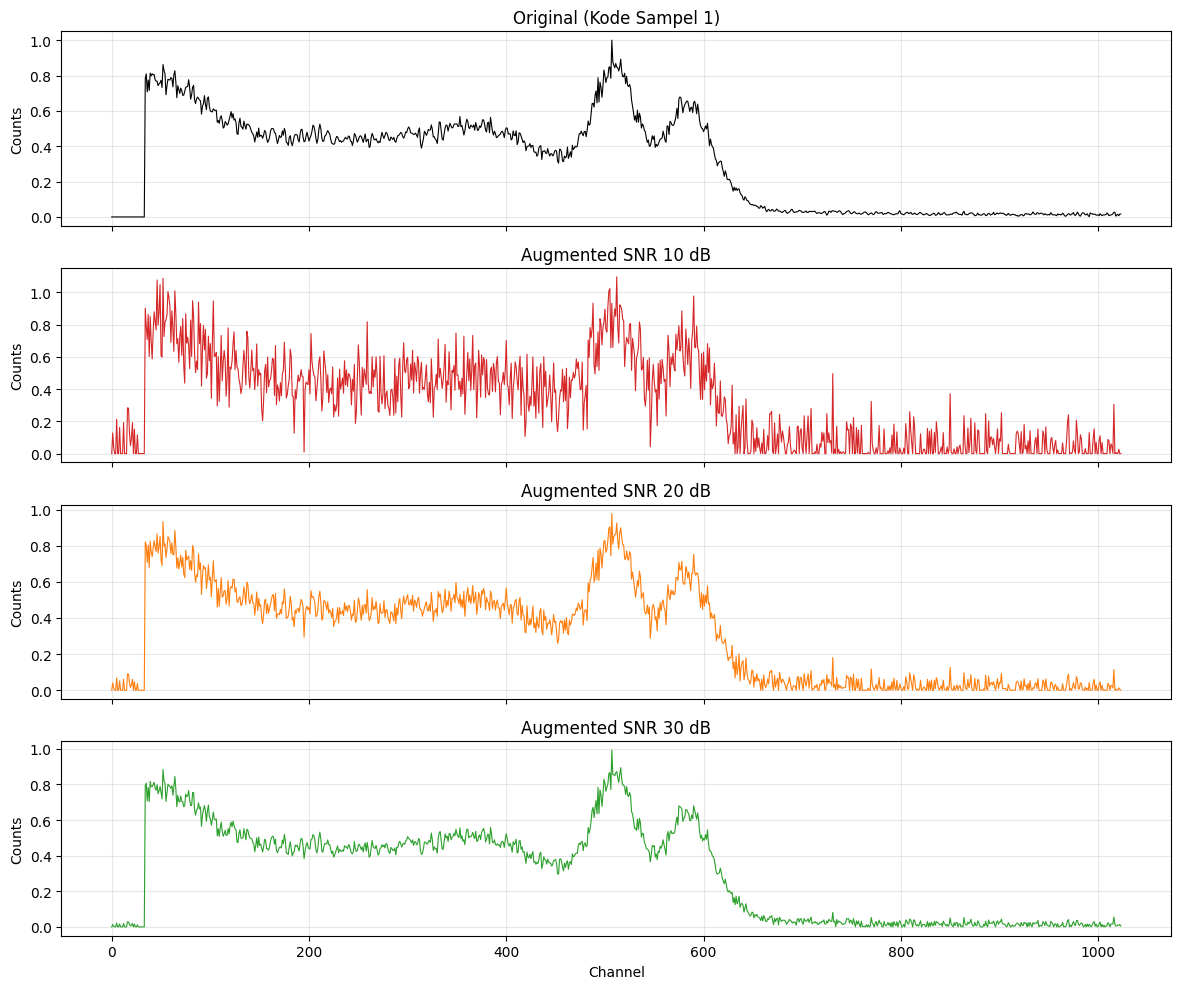

In [7]:
import matplotlib.pyplot as plt

# Ambil sampel pertama (index 0) dari grafik_channels asli
sample_orig = grafik_channels[0]
sample_kode = grafik_kode[0]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
channels_x = np.arange(N_CHANNELS)

axes[0].plot(channels_x, sample_orig, color='black', linewidth=0.8)
axes[0].set_title(f'Original (Kode Sampel {sample_kode})')
axes[0].set_ylabel('Counts')
axes[0].grid(alpha=0.3)

warna = ['tab:red', 'tab:orange', 'tab:green']
for ax, snr, c in zip(axes[1:], SNR_LEVELS, warna):
    np.random.seed(123)  # supaya plot reproducible (terpisah dari augmented utama)
    augmented = add_gaussian_noise(sample_orig, snr)
    ax.plot(channels_x, augmented, color=c, linewidth=0.8)
    ax.set_title(f'Augmented SNR {snr} dB')
    ax.set_ylabel('Counts')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Channel')
plt.tight_layout()
plt.show()

## 8. Normalisasi Aktivitas (Min-Max per Isotop)

Setiap kolom isotop dinormalisasi independen ke rentang $[0, 1]$:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

dimana $x_{min}$ dan $x_{max}$ dihitung **per kolom isotop** (Co-60, Cs-137, Ra-226, Eu-152) dari seluruh data (3200 baris). Hasilnya disimpan di sheet baru bernama **`Aktivitas Normalisasi`** pada file yang sama. Sheet `Aktivitas` (data asli) tetap dipertahankan.

In [8]:
print("Membaca file Excel untuk normalisasi aktivitas ...")
t0 = time.time()

wb_in = openpyxl.load_workbook(OUTPUT_FILE, read_only=True, data_only=True)

# Baca semua sheet
klas_existing  = [list(r) for r in wb_in["Klasifikasi Multilabel"].iter_rows(values_only=True)]
print(f"  Klasifikasi : {len(klas_existing)} baris ({time.time()-t0:.1f}s)")

grafik_existing = [list(r) for r in wb_in["Grafik"].iter_rows(values_only=True)]
print(f"  Grafik      : {len(grafik_existing)} baris ({time.time()-t0:.1f}s)")

akt_existing = [list(r) for r in wb_in["Aktivitas"].iter_rows(values_only=True)]
print(f"  Aktivitas   : {len(akt_existing)} baris ({time.time()-t0:.1f}s)")

wb_in.close()

# Hitung min/max per kolom isotop (abaikan None)
isotop_names = ['Co-60', 'Cs-137', 'Ra-226', 'Eu-152']
per_col_values = [[], [], [], []]
for row in akt_existing[2:]:               # lewati 2 baris header
    for i in range(4):
        v = row[3 + i]                     # kolom Co-60 mulai index 3
        if v is not None:
            per_col_values[i].append(float(v))

print("\nStatistik per isotop (sebelum normalisasi):")
min_max = []
for name, vals in zip(isotop_names, per_col_values):
    mn, mx = min(vals), max(vals)
    min_max.append((mn, mx))
    print(f"  {name:<7s}: n={len(vals)}, min={mn:>10.2f}, max={mx:>10.2f}")

# Hitung normalisasi
norm_records = []
for row in akt_existing[2:]:
    no, kode, jenis = row[0], row[1], row[2]
    vals_norm = []
    for i in range(4):
        v = row[3 + i]
        if v is None:
            vals_norm.append(None)
        else:
            mn, mx = min_max[i]
            denom = mx - mn
            vals_norm.append((float(v) - mn) / denom if denom > 0 else 0.0)
    norm_records.append((no, kode, jenis, vals_norm))

print(f"\nTotal baris normalisasi: {len(norm_records)}")

Membaca file Excel untuk normalisasi aktivitas ...
  Klasifikasi : 17 baris (0.0s)
  Grafik      : 3201 baris (20.4s)
  Aktivitas   : 3202 baris (20.5s)

Statistik per isotop (sebelum normalisasi):
  Co-60  : n=1680, min=   7354.51, max=  13421.56
  Cs-137 : n=1680, min=   6210.40, max=   7964.72
  Ra-226 : n=1680, min=   2680.46, max=   5340.60
  Eu-152 : n=1680, min=   1663.43, max=   3269.56

Total baris normalisasi: 3200


In [9]:
print("Menulis ulang file dengan sheet 'Aktivitas Normalisasi' ...")
t1 = time.time()

workbook = xlsxwriter.Workbook(OUTPUT_FILE, {'constant_memory': True})
fmt_bold = workbook.add_format({'bold': True})

# --- Sheet 1: Klasifikasi Multilabel (tidak berubah) ---
ws1 = workbook.add_worksheet("Klasifikasi Multilabel")
for r_idx, row in enumerate(klas_existing):
    for c_idx, val in enumerate(row):
        if val is not None:
            ws1.write(r_idx, c_idx, val)

# --- Sheet 2: Grafik (tidak berubah) ---
ws2 = workbook.add_worksheet("Grafik")
for r_idx, row in enumerate(grafik_existing):
    if r_idx == 0:
        for c_idx, val in enumerate(row):
            if val is not None:
                ws2.write(r_idx, c_idx, val, fmt_bold)
    else:
        ws2.write_row(r_idx, 0, list(row))
    if r_idx > 0 and r_idx % 500 == 0:
        print(f"  Grafik: {r_idx}/{len(grafik_existing)-1} baris ({time.time()-t1:.1f}s)")
print(f"  Sheet Grafik selesai ({time.time()-t1:.1f}s)")

# --- Sheet 3: Aktivitas (tidak berubah) ---
ws3 = workbook.add_worksheet("Aktivitas")
for r_idx, row in enumerate(akt_existing):
    fmt = fmt_bold if r_idx < 2 else None
    for c_idx, val in enumerate(row):
        if val is not None:
            if fmt:
                ws3.write(r_idx, c_idx, val, fmt)
            else:
                ws3.write(r_idx, c_idx, val)

# --- Sheet 4: Aktivitas Normalisasi (BARU) ---
ws4 = workbook.add_worksheet("Aktivitas Normalisasi")

# Header baris 1
ws4.write(0, 0, "No",                            fmt_bold)
ws4.write(0, 1, "Kode Sampel",                   fmt_bold)
ws4.write(0, 2, "Jenis",                         fmt_bold)
ws4.write(0, 3, "Aktivitas (Normalisasi Min-Max)", fmt_bold)

# Header baris 2 (sub-header isotop)
for c_idx, h in enumerate(["Co-60", "Cs-137", "Ra-226", "Eu-152"], start=3):
    ws4.write(1, c_idx, h, fmt_bold)

# Data normalisasi
for r_idx, (no, kode, jenis, vals) in enumerate(norm_records, start=2):
    ws4.write(r_idx, 0, no)
    ws4.write(r_idx, 1, kode)
    ws4.write(r_idx, 2, jenis)
    for c_idx, v in enumerate(vals, start=3):
        if v is not None:
            ws4.write(r_idx, c_idx, v)

workbook.close()

import os
size_mb = os.path.getsize(OUTPUT_FILE) / 1024 / 1024
print(f"\nFile tersimpan : {OUTPUT_FILE}")
print(f"Ukuran file    : {size_mb:.1f} MB")
print(f"Waktu tulis    : {time.time()-t1:.1f}s")
print(f"Sheet sekarang : Klasifikasi Multilabel | Grafik | Aktivitas | Aktivitas Normalisasi")

Menulis ulang file dengan sheet 'Aktivitas Normalisasi' ...
  Grafik: 500/3200 baris (1.6s)
  Grafik: 1000/3200 baris (3.2s)
  Grafik: 1500/3200 baris (4.8s)
  Grafik: 2000/3200 baris (6.4s)
  Grafik: 2500/3200 baris (7.9s)
  Grafik: 3000/3200 baris (9.5s)
  Sheet Grafik selesai (10.1s)

File tersimpan : C:\Users\wahyu\OneDrive\TA & Skripsi\TA&Skripsi\Olah data (2)\DATA FIX (Sudah Augmentasi).xlsx
Ukuran file    : 35.4 MB
Waktu tulis    : 14.9s
Sheet sekarang : Klasifikasi Multilabel | Grafik | Aktivitas | Aktivitas Normalisasi
